Histogram

In [2]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

In [4]:
hr = pd.read_csv('Dataset/HR_Dataset Refresh.csv')
hr.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [5]:
clean_salary = hr['Salary']<102000
hr = hr[clean_salary]



<function matplotlib.pyplot.show(close=None, block=None)>

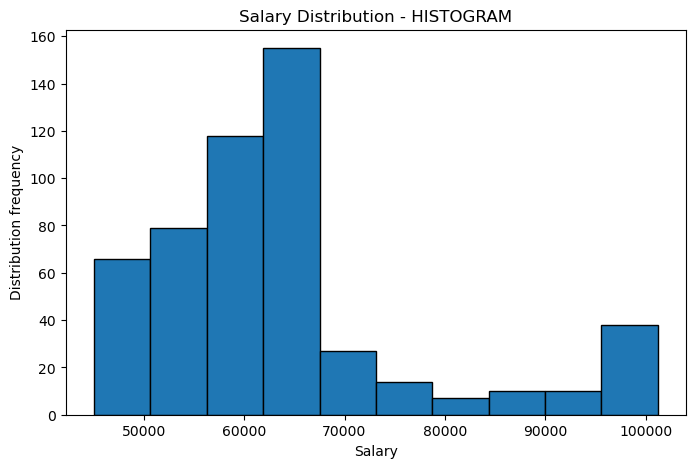

In [6]:
plt.figure(figsize=(8,5))
plt.hist(hr['Salary'], edgecolor = 'black')
plt.xlabel('Salary')
plt.ylabel('Distribution frequency')
plt.title('Salary Distribution - HISTOGRAM')
plt.show

In [7]:

import seaborn as sns

In [8]:
 mean_salary= hr['Salary'].mean()
median_salary = hr['Salary'].median()

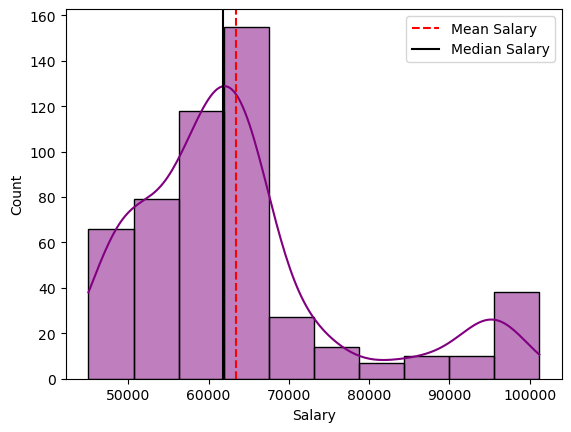

In [9]:
#KDE -> Kernel Density Estimate
# axvline -> axis vertical line
sns.histplot(hr['Salary'], bins=10, kde= True, color= 'purple')
plt.axvline(mean_salary, color ='red', label = 'Mean Salary', ls='--')
plt.axvline(median_salary, color ='black', label ='Median Salary' )
plt.legend()

BOX PLOT

In [11]:
clean_salary = hr['Salary']<80000
hr = hr[clean_salary]

<Axes: ylabel='Salary'>

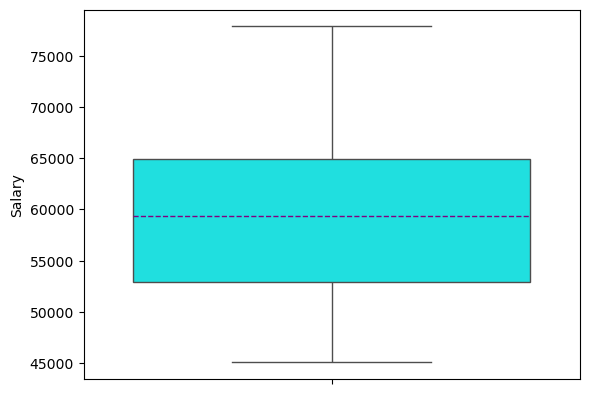

In [12]:
#wishker plot
#T-shape -> Wishkers ()
#If bigger above right skewness otherwise left 
#circle -> outlier 
sns.boxplot(hr['Salary'], color='aqua',medianprops={'color':'purple','linestyle':'--'})

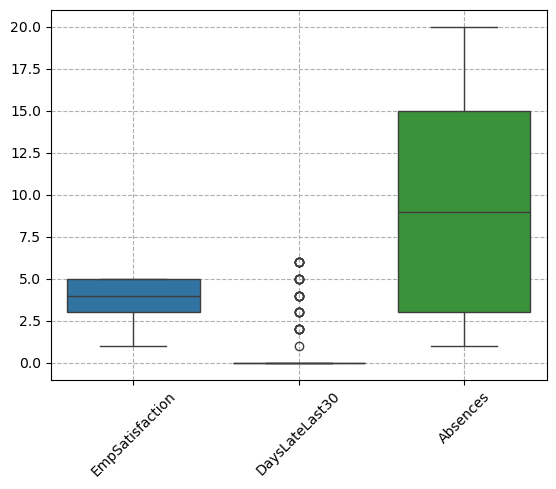

In [63]:
sns.boxplot(hr[['EmpSatisfaction','DaysLateLast30','Absences']])
plt.xticks(rotation=45)
plt.grid(ls='dashed')

BAR CHART(Column chart, stacked chart) 

In [15]:
#Find the employees by each department and its performance score.


In [16]:
dep_perf = hr.groupby(['Department', 'PerformanceScore'])['EmpID'].count().reset_index().rename(columns={'EmpID': 'Total_Employees'})

dep_perf

,Department,PerformanceScore,Total_Employees
0,Admin Offices,Fully Meets,6
1,IT/IS,Exceeds,1
2,IT/IS,Fully Meets,12
3,IT/IS,PIP,1
4,Production,Exceeds,85
5,Production,Fully Meets,301
6,Production,Needs Improvement,14
7,Production,PIP,8
8,Sales,Exceeds,2
9,Sales,Fully Meets,23


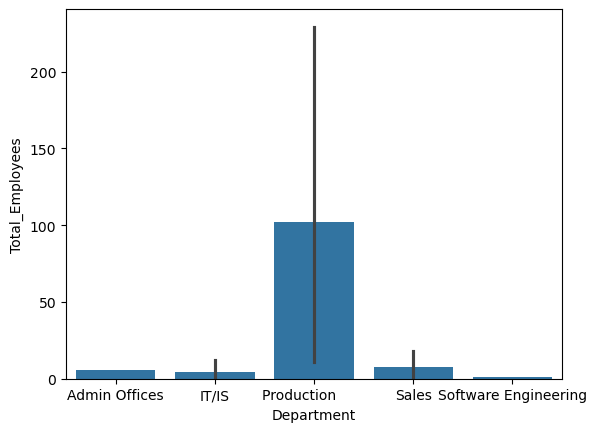

In [17]:
sns.barplot(data=dep_perf, x='Department', y='Total_Employees')
plt.show()


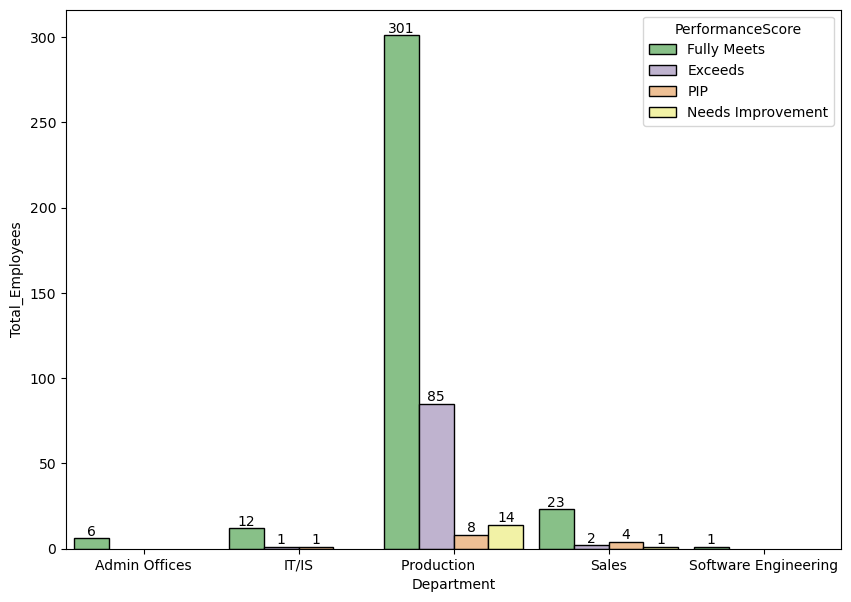

In [18]:
plt.figure(figsize=(10,7))
ax=sns.barplot(x='Department', y='Total_Employees', data=dep_perf, errorbar=None, hue='PerformanceScore',palette='Accent', width=0.9,edgecolor='black')
for container in ax.containers:
    plt.bar_label(container)


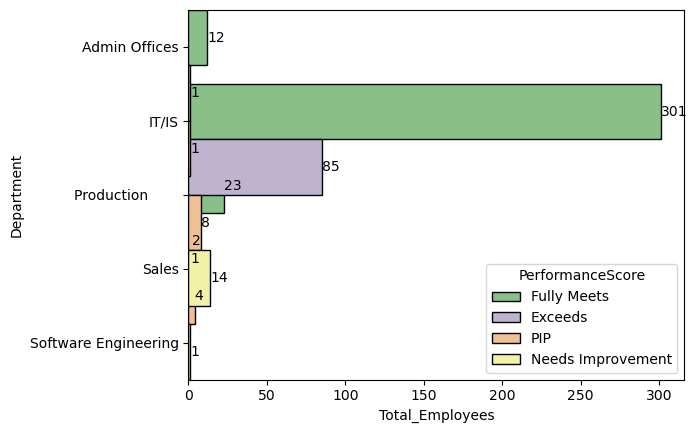

In [19]:
ax=sns.barplot(x='Total_Employees', y='Department', data=dep_perf, errorbar=None, hue='PerformanceScore',palette='Accent', width=3,edgecolor='black')
for container in ax.containers:
    plt.bar_label(container)

SUB-PLOT


In [75]:
''' 
Department
------------
total project count 
total absences
total employees 
total salary
'''
hr.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15


In [77]:
dep_detail= hr.groupby('Department').agg(
    Total_Employees= ('EmpID','count'),
    Total_Salary=('Salary','sum'),
    Total_Projects=('SpecialProjectsCount','sum'),
    Total_Absences=('Absences','sum')
).reset_index()
dep_detail

    

,Department,Total_Employees,Total_Salary,Total_Projects,Total_Absences
0,Admin Offices,6,347363,6,51
1,IT/IS,14,867678,14,149
2,Production,408,23909016,408,3812
3,Sales,30,1960899,30,339
4,Software Engineering,1,77692,1,4


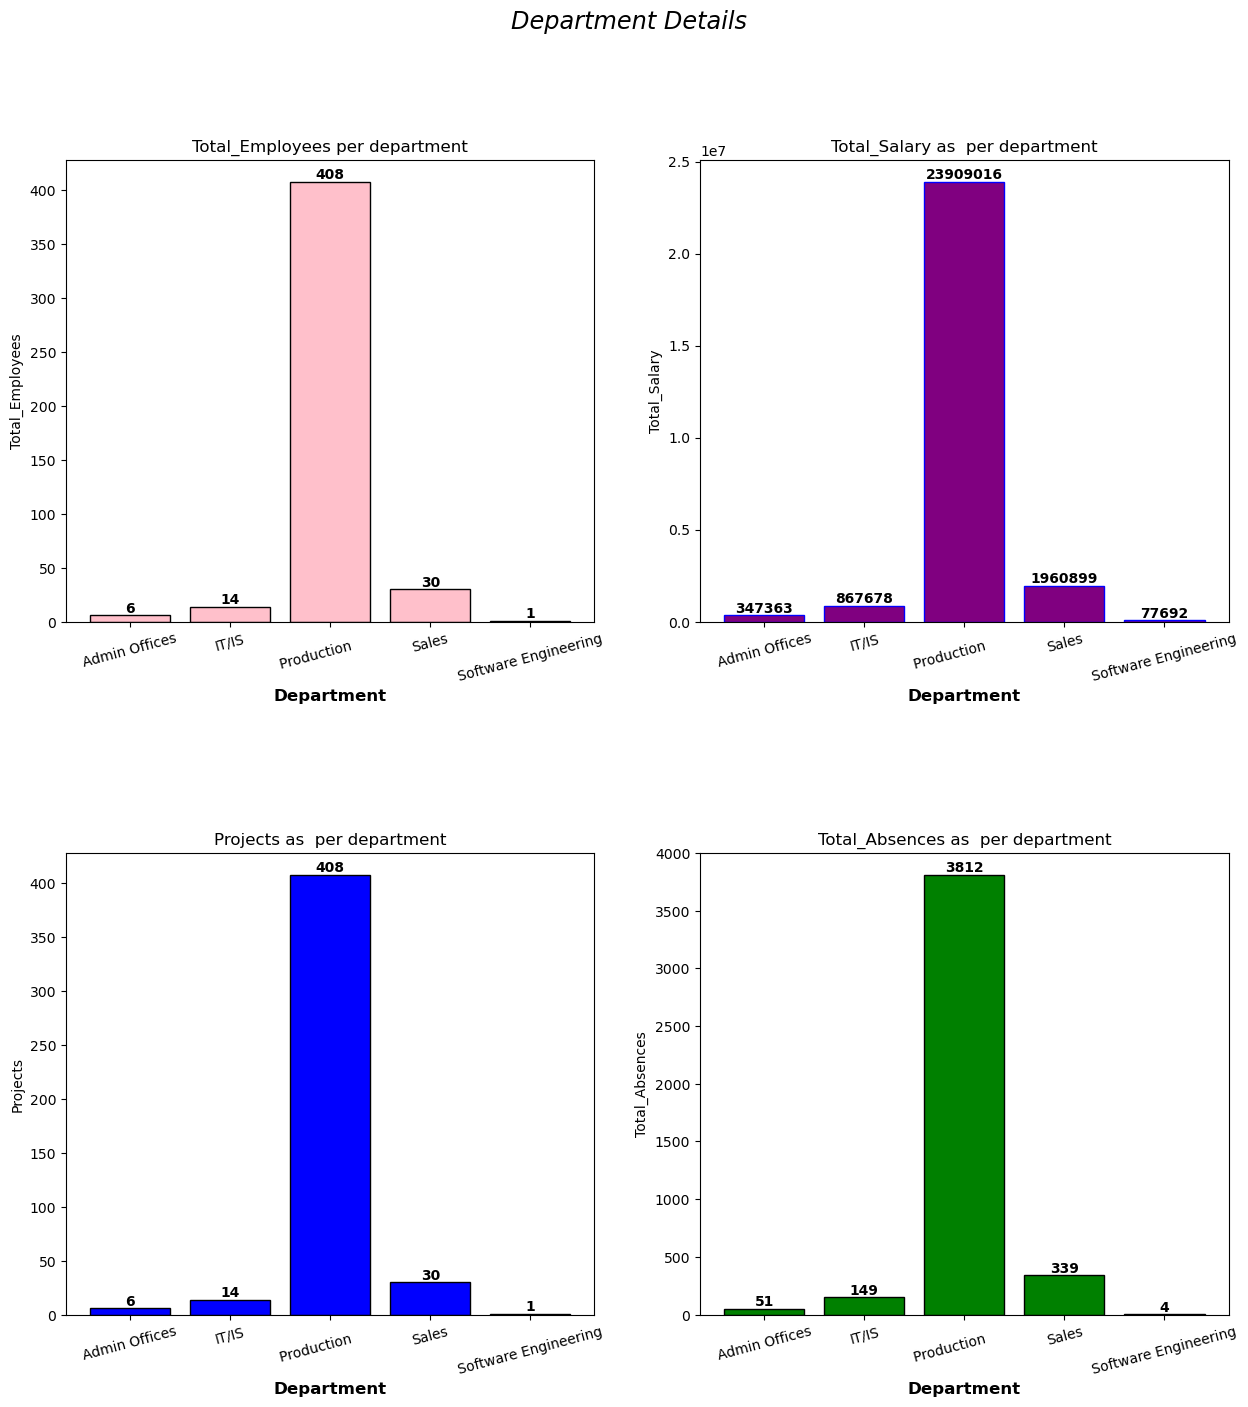

In [117]:
fig,axes=plt.subplots(2,2 ,figsize=(15,15))
ax1= axes[0,0]
ax2=axes[0,1]
plt.subplots_adjust(hspace=0.5)


plt.suptitle('Department Details', fontsize='xx-large',fontstyle='italic')
ax1.bar(dep_detail['Department'], dep_detail['Total_Employees'],color='pink',edgecolor='black')
ax1.set_xlabel('Department', fontweight='bold',fontsize='large')#fontstyle='italic'
ax1.set_ylabel('Total_Employees')
ax1.set_title('Total_Employees per department')
ax1.tick_params(axis='x',rotation=15)
for idx, val in enumerate(dep_detail['Total_Employees']):
    ax1.text(idx, val, str(val), ha='center', va='bottom', fontweight='bold')



ax2.bar(dep_detail['Department'], dep_detail['Total_Salary'],color='purple', edgecolor='blue')

ax2.tick_params(axis='x',rotation=15)
ax2.set_xlabel('Department', fontweight='bold', fontsize='large')#fontstyle='italic'
ax2.set_ylabel('Total_Salary')
ax2.set_title('Total_Salary as  per department')
ax2.tick_params(axis='x',rotation=15)
for idx, val in enumerate(dep_detail['Total_Salary']):
    ax2.text(idx, val, str(val), ha='center', va='bottom', fontweight='bold')




ax3=axes[1,0]
ax3.bar(dep_detail['Department'], dep_detail['Total_Projects'],color='blue',edgecolor='black')
ax3.set_xlabel('Department', fontweight='bold',fontsize='large')#fontstyle='italic'
ax3.set_ylabel('Projects')
ax3.set_title('Projects as  per department')
ax3.tick_params(axis='x',rotation=15)
for idx, val in enumerate(dep_detail['Total_Projects']):
    ax3.text(idx, val, str(val), ha='center', va='bottom', fontweight='bold')


ax4=axes[1,1]
ax4.bar(dep_detail['Department'], dep_detail['Total_Absences'],color='green',edgecolor='black')
ax4.set_xlabel('Department', fontweight='bold',fontsize='large')#fontstyle='italic'
ax4.set_ylabel('Total_Absences')
ax4.set_title('Total_Absences as  per department')
ax4.tick_params(axis='x',rotation=15)
for idx, val in enumerate(dep_detail['Total_Absences']):
    ax4.text(idx, val, str(val), ha='center', va='bottom', fontweight='bold')




